# ESM-C layer sweep: fabp7

Sweeps HDBSCAN clustering quality across all 31 ESM-C hidden-state layers (`layer_0` = embedding output before any transformer block, `layer_30` = final layer, same one used in `esmc_embedding_analysis_fabp7.ipynb`) on the same filtered pool, using the same HDBSCAN params already tuned for that pool at the final layer -- held fixed across layers here so the sweep isolates the effect of layer depth, not re-tuned HDBSCAN parameters.

Goal: figure out whether embedding usefulness for clustering scales monotonically with depth or peaks somewhere in the middle, before spending time on the full UMAP/medoid/wet-lab-selection/structural-overlay pipeline on any particular layer.

Embeddings computed via `inference/embed_esmc.py --layers all` on Waluigi (one forward pass per batch; every hidden_states layer pooled from the same pass, so this cost nothing extra over the original final-layer-only run).

In [1]:
import os
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

## Filter to well-scored designs (same as final-layer notebook)

In [2]:
# FABP7 thresholds (roughly p75 iptm / p90 ipsae / p10 ipae),
# same as esmc_embedding_analysis_fabp7.ipynb -- FABP7's pool is much
# harder than vilip1's, do not reuse vilip1's thresholds here.

# NOTE: this notebook lives at notebooks/bridget/esmc_embedding_analysis/ --
# three directories deep from the repo root, so data paths need ../../../.
MANIFEST_PATH = "../../../data/fabp7_full20k/manifest_with_ipsae.csv"
EMBEDDINGS_PATH = "../../../data/fabp7_full20k/embeddings_all_layers.npz"
# Sweep outputs land in a layer_sweep/ subfolder so they don't clobber the
# final-layer analysis files already in clustering/.
OUTPUT_DIR = "../../../data/fabp7_full20k/clustering/layer_sweep"
os.makedirs(OUTPUT_DIR, exist_ok=True)

manifest = pd.read_csv(MANIFEST_PATH)

IPTM_MIN = 0.7
IPSAE_MIN = 0.35
IPAE_MAX = 10.0
BINDING_CONFIDENCE_MIN = 0.01

filtered_manifest = manifest[
    (manifest["iptm"] > IPTM_MIN)
    & (manifest["ipsae"] > IPSAE_MIN)
    & (manifest["ipae"] < IPAE_MAX)
    & (manifest["binding_confidence"] > BINDING_CONFIDENCE_MIN)
].copy()

print(
    f"{len(filtered_manifest)}/{len(manifest)} designs pass " + f"iptm>{IPTM_MIN}, ipsae>{IPSAE_MIN}, ipae<{IPAE_MAX}" + f", binding_confidence>{BINDING_CONFIDENCE_MIN}"
)

filtered_ids = set(filtered_manifest["id"])


678/20000 designs pass iptm>0.7, ipsae>0.35, ipae<10.0, binding_confidence>0.01


## Load all-layer embeddings, restrict to filtered pool

In [3]:
npz = np.load(EMBEDDINGS_PATH, allow_pickle=True)
all_ids = npz["ids"]
keep_mask = np.array([eid in filtered_ids for eid in all_ids])
protein_names = all_ids[keep_mask].tolist()

layer_keys = sorted(
    [k for k in npz.files if k.startswith("layer_")],
    key=lambda k: int(k.split("_")[1]),
)
layer_indices = [int(k.split("_")[1]) for k in layer_keys]
print(f"Loaded {len(all_ids)} embeddings, kept {keep_mask.sum()} after filtering, {len(layer_keys)} layers ({layer_indices[0]}..{layer_indices[-1]})")

# L2-normalize each layer's filtered embeddings up front (HDBSCAN below runs
# euclidean distance, which on unit-norm vectors is equivalent to cosine --
# same convention as esmc_embedding_analysis_fabp7.ipynb).
X_by_layer = {
    idx: normalize(npz[f"layer_{idx}"][keep_mask], norm="l2", axis=1)
    for idx in layer_indices
}

Loaded 20000 embeddings, kept 678 after filtering, 31 layers (0..30)


## Sweep HDBSCAN across every layer

In [4]:
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3

sweep_rows = []
for idx in layer_indices:
    X = X_by_layer[idx]
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean",
        prediction_data=True,
    )
    labels = clusterer.fit_predict(X)

    n_total = len(labels)
    n_noise = int(np.sum(labels == -1))
    unique_clusters = set(labels) - {-1}
    n_clusters = len(unique_clusters)

    non_noise = labels != -1
    if n_clusters >= 2 and non_noise.sum() >= 2:
        sil = silhouette_score(X[non_noise], labels[non_noise], metric="cosine")
    else:
        sil = float("nan")

    sweep_rows.append({
        "layer": idx,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_frac": n_noise / n_total,
        "silhouette": sil,
    })
    print(f"layer {idx:>2}: clusters={n_clusters:>3}  noise={n_noise:>5}/{n_total} ({n_noise/n_total:.1%})  silhouette={sil:.4f}")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(f"{OUTPUT_DIR}/layer_sweep_summary.csv", index=False)
print(f"\nSaved {OUTPUT_DIR}/layer_sweep_summary.csv")

layer  0: clusters=  2  noise=  225/678 (33.2%)  silhouette=0.3559
layer  1: clusters=  2  noise=  588/678 (86.7%)  silhouette=0.1174
layer  2: clusters=  3  noise=  505/678 (74.5%)  silhouette=0.3263
layer  3: clusters=  2  noise=  555/678 (81.9%)  silhouette=0.5141
layer  4: clusters=  2  noise=  407/678 (60.0%)  silhouette=0.4172
layer  5: clusters=  2  noise=  147/678 (21.7%)  silhouette=0.3794
layer  6: clusters=  6  noise=  464/678 (68.4%)  silhouette=0.3033
layer  7: clusters=  2  noise=   97/678 (14.3%)  silhouette=0.3018
layer  8: clusters=  3  noise=  151/678 (22.3%)  silhouette=0.3219
layer  9: clusters=  2  noise=  156/678 (23.0%)  silhouette=0.2780
layer 10: clusters=  3  noise=  286/678 (42.2%)  silhouette=0.1573
layer 11: clusters=  3  noise=  270/678 (39.8%)  silhouette=0.1706
layer 12: clusters=  3  noise=  302/678 (44.5%)  silhouette=0.1986
layer 13: clusters=  4  noise=  254/678 (37.5%)  silhouette=0.2122
layer 14: clusters=  4  noise=  338/678 (49.9%)  silhouette=0.

## Plot clustering quality vs. layer depth

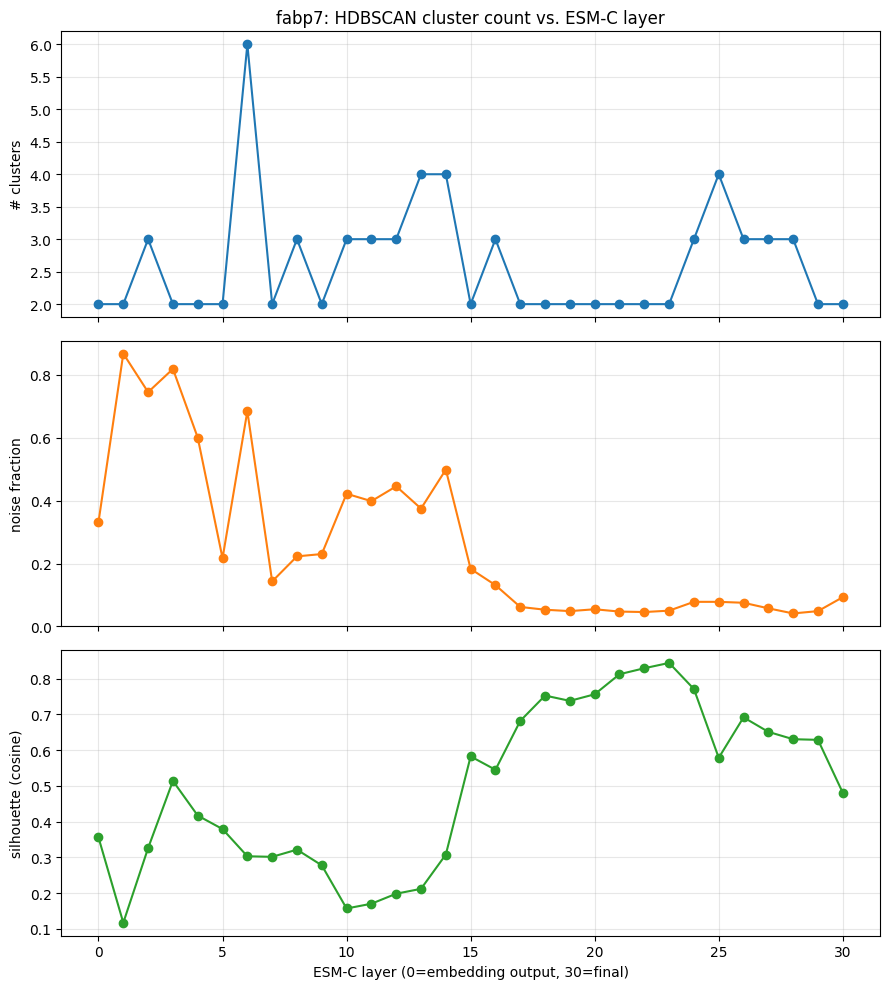

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(sweep_df["layer"], sweep_df["n_clusters"], marker="o")
axes[0].set_ylabel("# clusters")
axes[0].set_title("fabp7: HDBSCAN cluster count vs. ESM-C layer")

axes[1].plot(sweep_df["layer"], sweep_df["noise_frac"], marker="o", color="tab:orange")
axes[1].set_ylabel("noise fraction")

axes[2].plot(sweep_df["layer"], sweep_df["silhouette"], marker="o", color="tab:green")
axes[2].set_ylabel("silhouette (cosine)")
axes[2].set_xlabel("ESM-C layer (0=embedding output, 30=final)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/layer_sweep.png", dpi=200)
plt.show()

## Candidate layers for the full deep-dive pipeline

In [6]:
# Ranks layers by silhouette among those that actually found >=2 clusters
# without collapsing to mostly noise (noise_frac < 0.5) -- a layer that puts
# everything in one cluster or calls everything noise isn't a useful
# clustering, whatever its silhouette says.
candidates = sweep_df[
    (sweep_df["n_clusters"] >= 2) & (sweep_df["noise_frac"] < 0.5)
].sort_values("silhouette", ascending=False)

print("Top candidate layers by silhouette (n_clusters>=2, noise<50%):")
print(candidates.head(10).to_string(index=False))

print("\nFinal layer (30) for reference:")
print(sweep_df[sweep_df["layer"] == 30].to_string(index=False))

Top candidate layers by silhouette (n_clusters>=2, noise<50%):
 layer  n_clusters  n_noise  noise_frac  silhouette
    23           2       34    0.050147    0.844290
    22           2       31    0.045723    0.829408
    21           2       32    0.047198    0.812658
    24           3       53    0.078171    0.771222
    20           2       37    0.054572    0.756537
    18           2       36    0.053097    0.752954
    19           2       33    0.048673    0.738096
    26           3       51    0.075221    0.692015
    17           2       42    0.061947    0.682076
    27           3       39    0.057522    0.651393

Final layer (30) for reference:
 layer  n_clusters  n_noise  noise_frac  silhouette
    30           2       63     0.09292     0.48104
